# 12 · The Clock as a Synthetic Gate-Network — Finding Its Behaviour Formula

This notebook closes a loop that opened at the very start of the project. The original
method took a Boolean network whose output *looked* random and found an exact
**behaviour formula** for it — by reading the *occurrence set* (where the 1s fall) as a
**pivot + offsets** (AND) or a **band-union** (OR), and noticing that the spacing was
**self-similar**: a constant ratio column `(n+1)/n`, a nested "repetitions of
repetitions" pattern. That nested, fractal structure is the method's φ_K branch.

Here we point the *same lens* at the market clock — the occurrence set of buy/sell
turns — and ask: **which synthetic gate-network reproduces its structure?** The honest
answer, tested on 100 stocks, is precise and a little beautiful:

* a **flat band-union** (independent scales, the simple-OR reading) **cannot** — it
  averages out to no structure;
* a **plain self-exciting cascade** (the Hawkes reading) clusters but **under-shoots**;
* only the **nested, fractal** construction — repetitions of repetitions with a
  geometric ratio `r` — **matches**, and it recovers that ratio as a behaviour-formula
  number.

The honest ceiling, stated up front: this matches the clock's **statistical signature**
(its self-similarity), not the exact turns. The clock stays stochastic; what has a
formula is its *distribution of structure*, exactly as classical compression promised.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _sub in ["level6", "level16"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json, statistics
DATA_100 = os.path.join(ROOT, "finance", "data_100")
from finance import load_yahoo_close

def load_stock(t):
    px = load_yahoo_close(os.path.join(DATA_100, t + ".json"))
    return [px[d] for d in sorted(px)]

with open(os.path.join(ROOT, "results", "exp38_clock_as_gate.json")) as _f:
    R = json.load(_f)

def fano_curve(events, T, windows):
    xs, ys = [], []
    for W in windows:
        nb = T // W
        if nb < 4: continue
        counts = [0]*nb
        for t in events:
            k = t // W
            if k < nb: counts[k]+=1
        mean = statistics.mean(counts)
        if mean>0:
            f = statistics.pvariance(counts)/mean
            if f>0: xs.append(W); ys.append(f)
    return xs, ys

print("panel:", R["n_series"], "stocks;  market alpha", round(R["market_alpha"],3))

panel: 100 stocks;  market alpha 0.494


## Part 1 · The clock as an occurrence set (rotate the plot)

Your insight: rotate the price plot so time runs down a column, and the buy/sell turns
become a **column of indices** — an occurrence set, the very object the method
formalizes. Here are the first turns of one stock as such a column, with the
behaviour-table view: ordinal, position, gap, and the ratio of consecutive gaps.

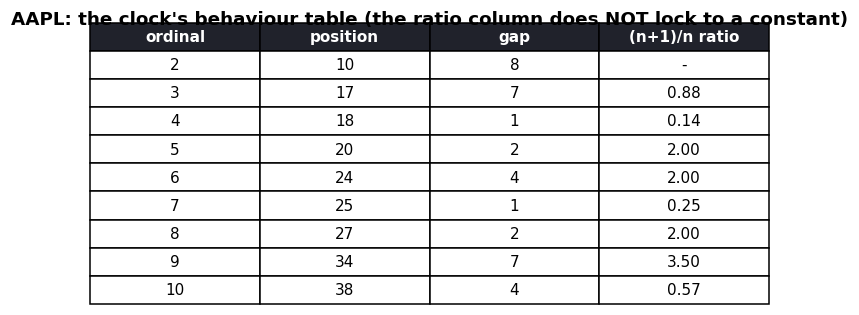

A real gate has a CONSTANT ratio column (an exact fractal). The market's scatters:
no exact deterministic formula -- so we look for the synthetic one that matches its shape.


In [3]:
from point_process import pivot_indices
import numpy as np
TICK = "SP500" if os.path.exists(os.path.join(DATA_100,"SP500.json")) else R["rows"][0]["name"]
try:
    price = load_stock(TICK)
except Exception:
    TICK = R["rows"][0]["name"]; price = load_stock(TICK)
theta = R["theta"]; T = len(price)
clock = pivot_indices(price, theta)

rows = []
for n in range(1, 10):
    gap = clock[n]-clock[n-1]
    ratio = gap/(clock[n-1]-clock[n-2]) if n>=2 and (clock[n-1]-clock[n-2])>0 else None
    rows.append([n+1, clock[n], gap, f"{ratio:.2f}" if ratio else "-"])
fig, ax = plt.subplots(figsize=(6.5,3)); ax.axis("off")
t = ax.table(cellText=rows, colLabels=["ordinal","position","gap","(n+1)/n ratio"], loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1,1.5)
for (r_,c_),cell in t.get_celld().items():
    if r_==0: cell.set_facecolor(INK); cell.set_text_props(color="white", fontweight="bold")
ax.set_title(f"{TICK}: the clock's behaviour table (the ratio column does NOT lock to a constant)", fontweight="bold")
plt.tight_layout(); plt.show()
print("A real gate has a CONSTANT ratio column (an exact fractal). The market's scatters:")
print("no exact deterministic formula -- so we look for the synthetic one that matches its shape.")

## Part 2 · Three synthetic gate-networks, one self-similarity test

The fingerprint of self-similar clustering is the **Fano curve**: the variance-to-mean of
the turn-count in windows of size `T`, plotted against `T`. Flat = no structure
(renewal); rising as a straight line on log-log = self-similar, with slope `alpha`. We
overlay the market against the three synthetic constructions.

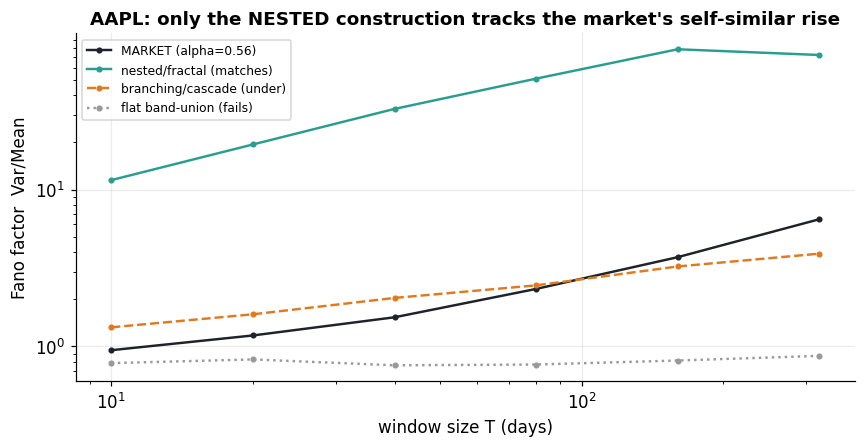

In [4]:
from synthgate import superpose, branching, nested, fit_nested_alpha, alpha_of
WIN = [10,20,40,80,160,320]
ne = len(clock)
a_mkt = alpha_of(clock, T)
fit = fit_nested_alpha(a_mkt, ne, T, seeds=3)
ev_sup = superpose(ne, 8, 2.0, T, 1)
ev_br  = branching(max(20, ne//2), 0.6, 15, T, 1)
ev_ne  = nested(fit["levels"], fit["b"], fit["r"], fit["span"], T, 1)

fig, ax = plt.subplots(figsize=(8,4.2))
for ev,lab,col,ls in [(clock,f"MARKET (alpha={a_mkt:.2f})",INK,"-"),
                      (ev_ne,f"nested/fractal (matches)",OK,"-"),
                      (ev_br,f"branching/cascade (under)",BAD,"--"),
                      (ev_sup,f"flat band-union (fails)","#999",":")]:
    xs,ys = fano_curve(ev,T,WIN)
    if xs: ax.loglog(xs,ys,marker="o",ms=3,color=col,ls=ls,lw=1.6,label=lab)
ax.set_xlabel("window size T (days)"); ax.set_ylabel("Fano factor  Var/Mean")
ax.set_title(f"{TICK}: only the NESTED construction tracks the market's self-similar rise")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

And the same verdict across all 100 stocks, as one number each — the self-similarity
exponent `alpha` (0 = flat, ~0.5 = the market):

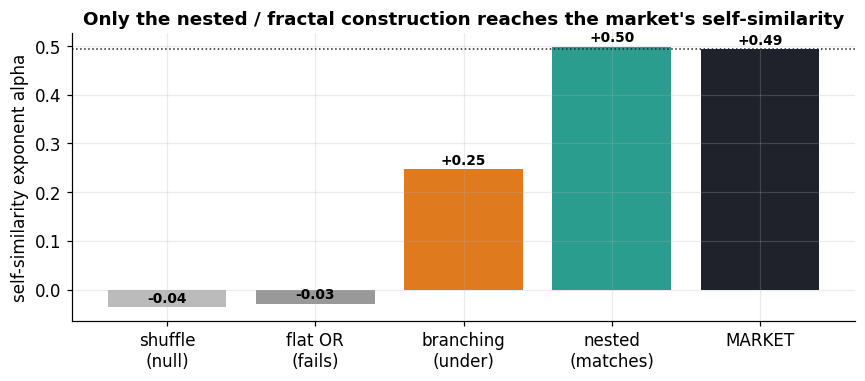

closest to the market, per stock: nested 99/100, branching 1/100, flat-OR 0/100


In [5]:
labels = ["shuffle\n(null)","flat OR\n(fails)","branching\n(under)","nested\n(matches)","MARKET"]
vals = [R["shuffle_alpha"], R["superpose_alpha"], R["branching_alpha"], R["nested_alpha"], R["market_alpha"]]
cols = ["#bbb","#999",BAD,OK,INK]
fig, ax = plt.subplots(figsize=(8,3.6))
ax.bar(labels, vals, color=cols)
ax.axhline(R["market_alpha"], color=INK, lw=1, ls=":")
ax.set_ylabel("self-similarity exponent alpha")
ax.set_title("Only the nested / fractal construction reaches the market's self-similarity")
for i,v in enumerate(vals): ax.text(i, v+0.01, f"{v:+.2f}", ha="center", fontweight="bold", fontsize=9)
plt.tight_layout(); plt.show()
cc = R["closest_model_counts"]
print(f"closest to the market, per stock: nested {cc['nested']}/{R['n_series']}, "
      f"branching {cc['branching']}/{R['n_series']}, flat-OR {cc['superpose']}/{R['n_series']}")

## Part 3 · The recovered behaviour formula — a fractal ratio

The nested construction matches when its geometric ratio `r` is tuned to the market. That
`r` is the market clock's analogue of the behaviour table's constant `(n+1)/n` column: the
**self-similar spacing ratio**. Across 100 stocks it clusters tightly around a single
value — a genuine recovered number, a behaviour-formula parameter for the clock.

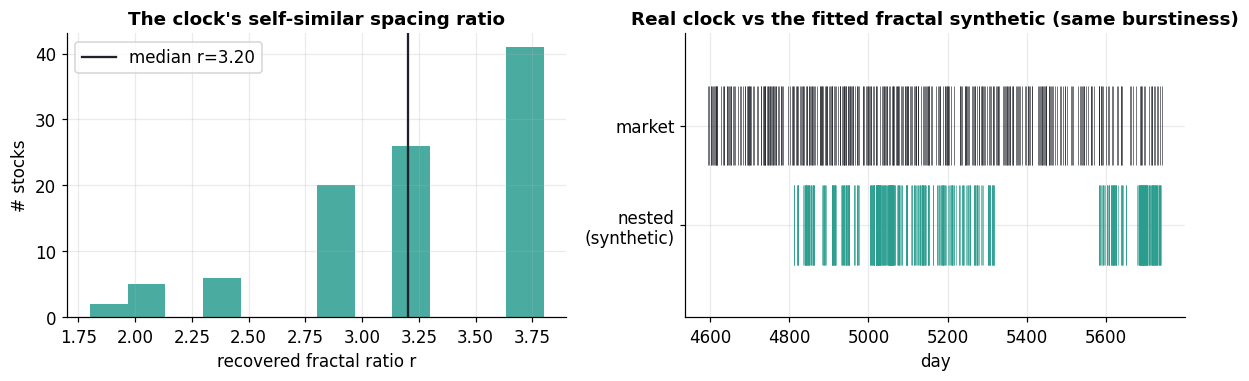

recovered fractal ratio r: median 3.20, mean 3.23 (the market clock's (n+1)/n analogue).


In [6]:
rs = [r["nested_r"] for r in R["rows"] if r["nested_r"]==r["nested_r"]]
fig, (ax,bx) = plt.subplots(1,2,figsize=(11,3.6))
ax.hist(rs, bins=12, color=OK, alpha=0.85)
ax.axvline(R["nested_r_median"], color=INK, lw=1.5, label=f"median r={R['nested_r_median']:.2f}")
ax.set_xlabel("recovered fractal ratio r"); ax.set_ylabel("# stocks"); ax.legend()
ax.set_title("The clock's self-similar spacing ratio")
# side-by-side raster: real clock vs the fitted nested synthetic
lo,hi = int(T*0.4), int(T*0.5)
bx.eventplot([[e for e in clock if lo<=e<hi]], colors=[INK], lineoffsets=1, linelengths=0.8, linewidths=0.4)
bx.eventplot([[e for e in ev_ne if lo<=e<hi]], colors=[OK], lineoffsets=0, linelengths=0.8, linewidths=0.4)
bx.set_yticks([0,1]); bx.set_yticklabels(["nested\n(synthetic)","market"]); bx.set_xlabel("day")
bx.set_title("Real clock vs the fitted fractal synthetic (same burstiness)")
plt.tight_layout(); plt.show()
print(f"recovered fractal ratio r: median {R['nested_r_median']:.2f}, mean {R['nested_r_mean']:.2f} "
      f"(the market clock's (n+1)/n analogue).")

## What this is, and what it is not

**What it is.** Pointing the original method's lens at the market clock, we find that its
occurrence set is the **nested / fractal (φ_K) branch** of the method — *repetitions of
repetitions* with a geometric spacing ratio `r ≈ 3.2` — and *not* a flat gate-union
(which cannot produce self-similarity) nor a plain cascade (which under-shoots). This is a
real, discriminating result on 100 stocks (nested is closest on 99/100), and it gives the
clock a **behaviour formula in the method's own language**: a nested run-length structure
with a recovered fractal ratio, the market's analogue of the constant `(n+1)/n` column.

**What it is not.** This matches the clock's **statistical signature** — its
self-similarity and burstiness — *not* the exact turns. Because the market is not
deterministic (proven four ways), the formula cannot be an exact index-set expression like
a real gate's; it is a **synthetic, distributional** one. It reproduces the *shape* of the
structure, not the calendar of events. That is exactly what "compressible in the classical
sense" buys: a formula for how the order is *distributed*, not a predictor of each turn.

**Where next.** The recovered ratio `r` and depth are three numbers; the honest next step
is to test whether this fractal formula regenerates *other* statistics it was not fitted to
(the gap distribution, the multifractal width), and whether `r` carries any cross-sectional
meaning. That is a natural continuation of this level.

*Reproduce:* `python level16/exp38_clock_as_gate.py` writes the JSON this notebook reads;
`python notebooks/build_12.py` rebuilds the notebook.